In [7]:
import openseespywin as ops
import opsvis as opsv 
import numpy as np
import ipywidgets as widgets
import os
import matplotlib.pyplot as plt
import math
import opstool as opst
#import eurocodepy as ecpy
import time as tt
import gmsh
# import openseespy.postprocessing.Get_Rendering as opsplt

In [8]:
import sys
sys.path.append('Data')
import functions.slope_d as Slp
import importlib
importlib.reload(Slp)
from functions.solver_function import *

Length: 0.001 1e-06 0.01 1
Force 0.001 1
Stress 1000.0 1.0 0.001
Mass 1e-06 0.001 1.0
<UnitSystem: length='m', force='kn', time='sec' (153100488105)>


In [9]:
length_unit = "m"  # base unit
force_unit = "KN"  # base unit

UNIT = opst.pre.UnitSystem(length=length_unit, force=force_unit)

print("Length:", UNIT.mm, UNIT.mm2, UNIT.cm, UNIT.m,)
print("Force", UNIT.N, UNIT.kN, )
print("Stress", UNIT.MPa, UNIT.kPa, UNIT.Pa, )
print("Mass", UNIT.g, UNIT.kg, UNIT.ton)
print(UNIT)

Length: 0.001 1e-06 0.01 1
Force 0.001 1
Stress 1000.0 1.0 0.001
Mass 1e-06 0.001 1.0
<UnitSystem: length='m', force='kn', time='sec' (153104156872)>


In [10]:
lc = 0.3

# Initialize Gmsh
import gmsh
import sys

gmsh.initialize()
gmsh.model.add("fused_shapes")
occ = gmsh.model.occ

# --- Rectangles ---
rect1 = occ.addRectangle(0, 0, 0, 15, 4)

# --- Triangle beside rect2 ---
p1 = occ.addPoint(5, 4, 0)
p2 = occ.addPoint(15, 4, 0)
p3 = occ.addPoint(15, 8, 0)
p4 = occ.addPoint(12, 8, 0)
l5 = occ.addLine(p1, p2)
l6 = occ.addLine(p2, p3)
l7 = occ.addLine(p3, p4)
l8 = occ.addLine(p4, p1)
triangle_loop = occ.addCurveLoop([l5, l6, l7, l8])
triangle = occ.addPlaneSurface([triangle_loop])

# --- Fragment everything ---
fused = occ.fragment([(2, rect1)], [(2, triangle)])

# --- Synchronize ---
occ.synchronize()

# --- Line Physical Groups ---
gmsh.model.addPhysicalGroup(1, [1], tag=201)
gmsh.model.setPhysicalName(1, 201, "bottom_support")

gmsh.model.addPhysicalGroup(1, [2], tag=202)
gmsh.model.setPhysicalName(1, 202, "right_bot_support")

gmsh.model.addPhysicalGroup(1, [6], tag=203)
gmsh.model.setPhysicalName(1, 203, "right_top_support")

gmsh.model.addPhysicalGroup(1, [5], tag=204)
gmsh.model.setPhysicalName(1, 204, "left_support")

gmsh.model.addPhysicalGroup(1, [l7], tag=205)
gmsh.model.setPhysicalName(1, 205, "loadings")

# --- Synchronize ---
occ.synchronize()
# --- Points to embed ---
embed_coords = [
    (11.2520, 6.2098, 0),
    (10.1450, 5.2189, 0),
    (8.6716, 4.1979, 0),
    (11.5000, 6.5000, 0),
    (11.0000, 5.5000, 0),
    (10.0000, 5.0000, 0),
    (9.0000, 3.5000, 0),
    (7.0000, 3.5000, 0),
    (6.0000, 3.0000, 0),
    (5.5000, 3.0000, 0),
    (5.0000, 2.5000, 0),
]

embed_pts_occ = [occ.addPoint(x, y, z, lc) for x, y, z in embed_coords]

# --- Synchronize ---
occ.synchronize()

# --- Embed points in triangle ---
# Helper to match 3D coordinates approximately
def coords_close(c1, c2, tol=1e-4):
    return all(isclose(a, b, abs_tol=tol) for a, b in zip(c1, c2))

# Get all 2D surfaces
surfaces = gmsh.model.getEntities(2)

# Build mapping of surface tag to bounding box
surface_boxes = {}
for dim, tag in surfaces:
    box = gmsh.model.getBoundingBox(dim, tag)
    surface_boxes[tag] = box

# Embed points into correct surface
for pt in embed_pts_occ:
    coord = gmsh.model.getValue(0, pt, [])
    x, y, z = coord

    for surf_tag, (xmin, ymin, zmin, xmax, ymax, zmax) in surface_boxes.items():
        if xmin <= x <= xmax and ymin <= y <= ymax:
            gmsh.model.mesh.embed(0, [pt], 2, surf_tag)
            print(f"Embedded point ({x:.3f}, {y:.3f}) to surface {surf_tag}")
            break

# --- Local refinement using Ball fields ---
ball_fields = []
for x, y, z in embed_coords:
    fid = gmsh.model.mesh.field.add("Ball")
    gmsh.model.mesh.field.setNumber(fid, "XCenter", x)
    gmsh.model.mesh.field.setNumber(fid, "YCenter", y)
    gmsh.model.mesh.field.setNumber(fid, "ZCenter", z)
    gmsh.model.mesh.field.setNumber(fid, "Radius", 1.0)
    gmsh.model.mesh.field.setNumber(fid, "VIn", 0.3)
    gmsh.model.mesh.field.setNumber(fid, "VOut", 0.5)
    ball_fields.append(fid)

# Combine Ball fields
min_field = gmsh.model.mesh.field.add("Min")
gmsh.model.mesh.field.setNumbers(min_field, "FieldsList", ball_fields)
gmsh.model.mesh.field.setAsBackgroundMesh(min_field)

# --- Mesh settings ---
gmsh.model.mesh.setSize(gmsh.model.getEntities(0), 0.5)


gmsh.model.addPhysicalGroup(2, [1], 301)
gmsh.model.setPhysicalName(2, 301, "soil_bot")

gmsh.model.addPhysicalGroup(2, [2], 302)
gmsh.model.setPhysicalName(2, 302, "soil_top")

# --- Generate mesh ---
gmsh.model.mesh.generate(2)
#gmsh.write("slope_c.msh")
#gmsh.fltk.run()
#gmsh.finalize()


Embedded point (11.252, 6.210) to surface 2
Embedded point (10.145, 5.219) to surface 2
Embedded point (8.672, 4.198) to surface 2
Embedded point (11.500, 6.500) to surface 2
Embedded point (11.000, 5.500) to surface 2
Embedded point (10.000, 5.000) to surface 2
Embedded point (9.000, 3.500) to surface 1
Embedded point (7.000, 3.500) to surface 1
Embedded point (6.000, 3.000) to surface 1
Embedded point (5.500, 3.000) to surface 1
Embedded point (5.000, 2.500) to surface 1


In [11]:
#model= Slp.build_model(friction_angle = friction_angles)

Info:: Geometry Information >>>
28 Entities: 18 Point; 8 Curves; 2 Surfaces; 0 Volumes.

Info:: Physical Groups Information >>>
7 Physical Groups.
Physical Group names: ['bottom_support', 'right_bot_support', 'right_top_support', 'left_support', 'loadings', 'soil_bot', 'soil_top']

Info:: Mesh Information >>>
668 Nodes; MaxNodeTag 668; MinNodeTag 1.
1378 Elements; MaxEleTag 1378; MinEleTag 1.



InitialStateAnalysis ON
InitialStateAnalysis OFF
Domain::addParameter - parameter with tag 0 already exists in model
after: 50 iterations  current Norm: 214.15 (max: 1e-05, Norm deltaR: 319906)
NewtonRaphson::solveCurrentStep() -the ConvergenceTest object failed in test()
StaticAnalysis::analyze() - the Algorithm failed at step: 0 with domain at load factor 12
OpenSees > analyze failed, returned: -3 error flag
after: 50 iterations  current Norm: 214.15 (max: 1e-05, Norm deltaR: 319906)
NewtonRaphson::solveCurrentStep() -the ConvergenceTest object failed in test()
StaticAnalysis::analyze() - the Algorithm failed at step: 0 with domain at load factor 12
OpenSees > analyze failed, returned: -3 error flag
after: 50 iterations  current Norm: 214.15 (max: 1e-05, Norm deltaR: 319906)
NewtonRaphson::solveCurrentStep() -the ConvergenceTest object failed in test()
StaticAnalysis::analyze() - the Algorithm failed at step: 0 with domain at load factor 12
OpenSees > analyze failed, returned: -3 err

OPSTOOL ::  All responses data with _odb_tag = 1 saved in .opstool.output/RespStepData-1.nc!

OPSTOOL ::  Loading all response data from .opstool.output/RespStepData-1.nc ...

Info:: Geometry Information >>>
28 Entities: 18 Point; 8 Curves; 2 Surfaces; 0 Volumes.

Info:: Physical Groups Information >>>
7 Physical Groups.
Physical Group names: ['bottom_support', 'right_bot_support', 'right_top_support', 'left_support', 'loadings', 'soil_bot', 'soil_top']

Info:: Mesh Information >>>
668 Nodes; MaxNodeTag 668; MinNodeTag 1.
1378 Elements; MaxEleTag 1378; MinEleTag 1.



InitialStateAnalysis ON
InitialStateAnalysis OFF
Domain::addParameter - parameter with tag 0 already exists in model
after: 50 iterations  current Norm: 201.368 (max: 1e-05, Norm deltaR: 324586)
NewtonRaphson::solveCurrentStep() -the ConvergenceTest object failed in test()
StaticAnalysis::analyze() - the Algorithm failed at step: 0 with domain at load factor 12
OpenSees > analyze failed, returned: -3 error flag
after: 50 iterations  current Norm: 201.368 (max: 1e-05, Norm deltaR: 324586)
NewtonRaphson::solveCurrentStep() -the ConvergenceTest object failed in test()
StaticAnalysis::analyze() - the Algorithm failed at step: 0 with domain at load factor 12
OpenSees > analyze failed, returned: -3 error flag
after: 50 iterations  current Norm: 201.368 (max: 1e-05, Norm deltaR: 324586)
NewtonRaphson::solveCurrentStep() -the ConvergenceTest object failed in test()
StaticAnalysis::analyze() - the Algorithm failed at step: 0 with domain at load factor 12
OpenSees > analyze failed, returned: -3 

OPSTOOL ::  All responses data with _odb_tag = 1 saved in .opstool.output/RespStepData-1.nc!

OPSTOOL ::  Loading all response data from .opstool.output/RespStepData-1.nc ...

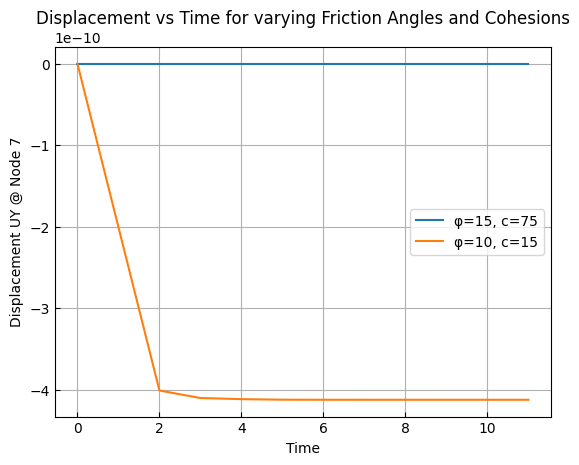

In [ ]:

def run_analysis_and_save(cohesion, friction_angle):
    ops.wipe()

    Slp.build_model(cohesion,friction_angle)

    ODB = opst.post.CreateODB(
        odb_tag=1,
        model_update=True,
        compute_mechanical_measures=True,
        project_gauss_to_nodes="copy",
    )

    def analysis_steps(nsteps=4):
        for _ in range(nsteps):
            ops.analyze(1)
            ODB.fetch_response_step()

    ops.analyze(1)
    analysis_steps(nsteps=10)

    ops.timeSeries("Linear", 1)
    ops.pattern("Plain", 1, 1)
    
    PN_1 = 5000  # Assuming UNIT.N = 1 or just use N directly
    #print("Load applied:", PN_1)

    ops.load(107, 0, -PN_1)
    ops.analyze(1)
    analysis_steps(nsteps=5)
    
    ops.load(106, 0, -PN_1)
    ops.analyze(1)
    analysis_steps(nsteps=5)
    
    ops.load(105, 0, -PN_1)
    ops.analyze(1)
    analysis_steps(nsteps=5)
    
    ops.load(104, 0, -PN_1)
    ops.analyze(1)
    analysis_steps(nsteps=5)

    ops.load(103, 0, -PN_1)
    ops.analyze(1)
    analysis_steps(nsteps=5)
    
    output_file = f"ODB_friction_{friction_angle}_cohesion_{cohesion}.npz"
    if os.path.exists(output_file):
        os.remove(output_file)

    ODB.save_response(output_file)

    NodalResp = opst.post.get_nodal_responses(odb_tag=1)
    time = NodalResp.time
    disp = NodalResp["disp"].sel(nodeTags=7, DOFs="UY")
    return time, disp


# Plot comparison
plt.figure()
cohesion = [75]
friction_angle = [0]

for coh, angle in zip(cohesion, friction_angle):
    time, disp = run_analysis_and_save(coh, angle)
    plt.plot(time, disp, label=f"φ={angle}, c={coh}")

plt.xlabel("Time")
plt.ylabel("Displacement UY @ Node 7")
plt.legend()
plt.grid(True)
plt.title("Displacement vs Time for varying Friction Angles and Cohesions")
plt.show()
